In [2]:
import numpy as np
import cvxpy as cp
from scipy.sparse import csr_matrix
import scipy as sp



####### Auxiliary functions#########################
I2 = np.identity(2)
Pauli = [I2, np.array([[0,1],[1,0]]), np.array([[0,0-1j],[0+1j,0]]), np.array([[1,0],[0,-1]])]
parties = 4
struct = parties*[4]
def prod(liste):
    aux = 1
    for i in range(len(liste)):
        aux = aux*liste[i]
    return aux

def e(j,N):
    aux = [0 for i in range(N)]
    aux[j] = 1
    return aux

def N(I,struct):
    aux = 1
    s = 0
    for i in range(len(I)):
        s += aux*I[i]
        aux = aux*struct[i]
    return s


def dec_to_bin(N,qubits):
    l = []
    m = N
    while m>=1:
        l.append(m%2)
        m = int((m-m%2)/2)
    while len(l)< qubits:
        l.append(0)
    return l



def cart_prod(L):
    aux = 1
    s = 0
    for i in range(len(L)):
        s = aux*(L[i])
        aux = aux*(L[i])
    prod=[]
    for j in range(s):
        x = [0 for i in range(len(L))]
        n = j
        for k in range(len(L)):
            x[k] = int(n % L[k])
            n = (n-x[k])//L[k]
        prod.append(x)
    return prod

def tensor_prod(liste):
    for i in range(len(liste)):
        if len(liste) > 2:
            return np.kron(liste[0],tensor_prod([liste[i] for i in range(1,len(liste))]))
        if len(liste ) == 2:
            return np.kron(liste[0],liste[1])
        if len(liste) == 1:
            return liste[0]
        if len(liste) == 0:
            return 1



def weight(liste):
    w = 0
    for i in range(len(liste)):
        if liste[i]!=0:
            w += 1
    return w


def E(i,j,D1,D2):
    M = np.zeros((D1,D2))
    M[i][j] = 1
    return M



def partial_trace_vectorized(rho,pts,n):
    aux = np.zeros()
    for I in cart_prod((n-len(pts))*[4]):
        ind = []
        ctr = 0
        while len(ind)<n:
            if len(ind) in pts:
                ind.append(I[ctr])
                ctr += 1
            else: ind.append(0)
    aux[N(I,(n-len(pts))*[4])] = 2**pts * rho[N(ind)]
    return   

def complement(pts,n):
    aux = []
    for i in range(n):
        if not i in pts:
            aux.append(i)
    return aux



def partial_transpose_ops(pts,n):
    aux = []
    for I in cart_prod(len(pts)*2*[2]):
        l = []
        ctr = 0
        for k in range(n):
            if k in pts:
                l.append(E(I[2*ctr],I[2*ctr+1],2,2))
                ctr += 1
            else:
                l.append(np.identity(2))
        aux.append(csr_matrix(tensor_prod(l)))
    return aux

def partial_trace_ops(pts,n,local_dim):
    aux = []
    for I in cart_prod(len(pts)*[local_dim]):
        l = []
        ctr = 0
        for k in range(n):
            if k in pts:
                l.append(np.array([e(I[ctr],local_dim)]))
                ctr += 1
            else:
                l.append(np.identity(local_dim))
        aux.append(csr_matrix(tensor_prod(l)))
    return aux

def adj(A):
    return np.conj(np.transpose(A))



In [11]:
def fidelity_lower_bound(eps,gamma,d):
    def fidelity_from_Choi(x,d):
        return (d+x)/(d*(d+1))
    Choi = np.zeros((d**2,d**2))
    for i in range(d):
        for j in range(d):
            Choi[j+j*d][i+i*d] = 1
    X = cp.Variable((d**2,d**2), hermitian=True)
    states = [E(j,j,d,d) for j in range(d)]
    states += [np.ones((d,d))/d]
    meas_bounds = d*[1-eps]
    meas_bounds += [1-gamma]
    constraints = [X>>0]
    partial_tr = partial_trace_ops([0],2,d)
    constraints += [sum([K@X@np.transpose(K) for K in partial_tr])==np.identity(d)]
    for j in range(d+1):
        constraints += [cp.real(cp.trace(X@np.kron(states[j],states[j])))>=meas_bounds[j]]
    prob = cp.Problem(cp.Minimize(cp.real(cp.trace(Choi @ X))), constraints)
    return 1-fidelity_from_Choi(prob.solve(),d)


In [26]:
sols = []
epsilons = [0.05,0.04,0.03,0.02,0.01,0.005,0.004,0.003,0.002,0.001,0.0005,0.0001,0.00005,0.00001]
for eps in epsilons:
    sols.append(fidelity_lower_bound(eps,eps,2))

In [22]:
sol2 = sols

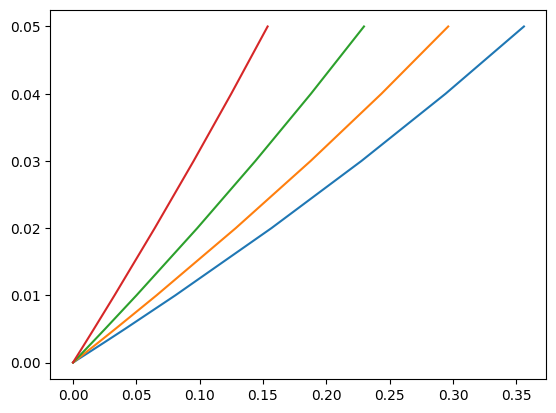

In [ ]:
from matplotlib import pyplot as plt
plt.plot(sol5,epsilons)
plt.plot(sol4,epsilons)
plt.plot(sol3,epsilons)
plt.plot(sol2,epsilons)
plt.show()

In [ ]:
[0.01,0.001,0.0005,0.0001]
[0.06597398724705195,0.006769604532895768,0.003416793415203734,0.0007485720102137217,8.009999083746777e-05,1.2544448440898748e-05,5.787798941669919e-06]

In [ ]:
data = 'n=10:0.14703'+'n = 7:0.1085574102570292'

In [ ]:
dp_2_to_8 = [0.03280200631622143,0.050136,0.06597398724705195,0.08082110429277523,0.09496092788038912,0.1085574102570292]

In [24]:
sol2

[np.float64(0.15366602499938065),
 np.float64(0.12496606719884085),
 np.float64(0.09527322219845535),
 np.float64(0.06455461426948916),
 np.float64(0.032802191903653743),
 np.float64(0.016539381032118494),
 np.float64(0.013250268067259596),
 np.float64(0.009955602447442646),
 np.float64(0.006652463030998312),
 np.float64(0.003326844321661415),
 np.float64(0.0016615489943095918),
 np.float64(0.0003358801531744282),
 np.float64(0.0001689435281191365),
 np.float64(3.537380427154346e-05)]

In [27]:
import csv
rows = zip(epsilons, sol2,sol3,sol4,sol5)

# Save to CSV
with open("output.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file, delimiter=",")
    writer.writerows(rows)